# ENCS5342 — Assignment #1
## Arabic Stemming, Lemmatization, and Regular Expressions

| | |
|---|---|
| **Course** | ENCS5342 — Information Retrieval with Applications of NLP |
| **Instructor** | Dr. Ahmed I. A. Shawahna — Birzeit University |
| **Semester** | Second Semester 2025–2026 |


| | Name | ID | Section |
|---|---|---|---|
| **Student 1** | leen Alqazaqi | 1220380 | Sec2 | 
| **Student 2** | Duha Imad | 1220623 | Sec2| 

---

## Grading & Submission

This assignment covers the use of **regular expressions** and **Python** for text processing,
and the application of **Arabic stemming and lemmatization** tools to a real multilingual corpus.

- Work in **groups of two students** (from any section).
- **Run all cells** in order before submitting. Output must be visible beneath each code cell.
- Where a question asks for discussion, add your written explanation in the **Markdown cell immediately below the code cell**.
- Submit a **single Jupyter Notebook file** named `A1_ID1_ID2.ipynb` (replace ID1 and ID2 with your student IDs).

---

## Before Starting

### Corpus: UN Parallel Corpus (UNCorpus)

This assignment uses the **United Nations General Assembly Resolutions Corpus (UNCorpus)**, a corpus of UN General Assembly resolutions. The UNCorpus is a six-language parallel text in Arabic, Chinese, English, French, Russian, and Spanish. The following paper describes the corpus:

> Rafalovitch, A. & Dale, R. (2009). *United Nations General Assembly Resolutions: A Six-Language Parallel Corpus.* Proceedings of MT Summit XII, Ottawa, Canada.  
> URL: http://web.science.mq.edu.au/~rdale/publications/papers/2009/MTS-2009-Rafalovitch.pdf

The portion of the UNCorpus used in this assignment is the file **`uncorpora_plain_20090831.tmx`**. This file is referred to as the **UNCorpus** throughout this document. It is stored in TMX format (Translation Memory eXchange), an XML-based standard for parallel corpora.

> **You can download the file from the following link:** https://drive.google.com/file/d/1AS1m3uzDL6B49xN4R7k2WWqOyRxP3QpI/view?usp=sharing  
> **Before running any cells:** place `uncorpora_plain_20090831.tmx` in the **same directory** as this notebook.

### Assignment Structure

| Section | Topic | Points |
|---------|-------|--------|
| **Section A** | Regular Expressions | 70 |
| **Section B** | Arabic Stemming and Lemmatization | 30 |
| | **Total** | **100** |


---
## Setup — Run This Cell First

This cell installs all required Python packages and loads the UNCorpus into memory. All subsequent cells depend on variables defined here. **Run this cell before any other.**

In [ ]:
import re, os, sys, subprocess
from collections import Counter, defaultdict

# Install required packages
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'nltk', 'tashaphyne', 'sinatools', 'matplotlib',
     '-q', '--disable-pip-version-check'],
    capture_output=True
)

import nltk
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
nltk.download('punkt', quiet=True)

# ── Load corpus ───────────────────────────────────────────────────
CORPUS_FILE = 'uncorpora_plain_20090831.tmx'

if not os.path.exists(CORPUS_FILE):
    print(f'ERROR: corpus file not found — {CORPUS_FILE}')
    print('Place the .tmx file in the same directory as this notebook.')
else:
    size_mb = os.path.getsize(CORPUS_FILE) / (1024 * 1024)
    with open(CORPUS_FILE, 'r', encoding='utf-8', errors='replace') as f:
        content   = f.read()
        f.seek(0)
        all_lines = f.readlines()
    print(f'Corpus file : {CORPUS_FILE}  ({size_mb:.1f} MB)')
    print(f'Lines loaded: {len(all_lines):,}')
    print('Setup complete.')


Corpus file : uncorpora_plain_20090831.tmx  (155.6 MB)
Lines loaded: 1,501,316
Setup complete.


---
# Section A: Regular Expressions (70 points)

All answers in this section must be obtained using **Python and the `re` module**. Use `re.search()`, `re.findall()`, or `re.sub()` as appropriate.

**How to present your answers:** Run the code cell for each question so that the output is visible beneath it, then write your written answer or discussion in the Markdown cell that follows.


---
### A0 (0 pt) — Worked Example: Lines Mentioning "Human Rights"

**Task:** Ignoring letter case, how many **lines** in the UNCorpus mention the phrase *Human Rights*?

This question is solved for you as a worked example illustrating the expected format: a code cell followed by a Markdown cell with the written answer.


In [ ]:
# A0 — Worked example
count_hr = sum(1 for line in all_lines
               if re.search(r'human rights', line, re.IGNORECASE))
print(f'{count_hr:,} lines mention "Human Rights" (case-insensitive).')


5,664 lines mention "Human Rights" (case-insensitive).


**Answer:** 5,664 lines of text mention the phrase *Human Rights*.


---
### A1 (5 pt) — XML Structure of the UNCorpus

**Task:** Use Python and regular expressions to investigate and describe the XML structure of the UNCorpus TMX file. Your written answer must identify:

- The root element and all key container elements.
- Which element holds one complete translation unit (a sentence in all six languages).
- Which element holds one language's version of a sentence, and how the language is identified.
- Which element contains the actual text of a segment.
- Any metadata or property elements present in the file.

Include the regex patterns you used to discover each structural feature.


In [ ]:
#  Investigate XML structure
tags = re.findall(r"<[^>]+>", content)

unique_tags = sorted(set(tags))

print("Unique tags:")
for tag in unique_tags:
    print(tag)




Unique tags:
</body>
</prop>
</seg>
</tmx>
</tu>
</tuv>
<?xml version="1.0" encoding="UTF-8"?>
<body>
<header segtype="paragraph" creationtoolversion="1.0" srclang="EN" creationtool="ORESAligner" datatype="plaintext" o-tmf="ORES" adminlang="en-us"/>
<prop type="committee">
<prop type="lead">
<prop type="session">
<seg>
<tmx version="1.4b">
<tu tuid="55_100:11">
<tu tuid="55_100:12">
<tu tuid="55_100:13">
<tu tuid="55_100:14">
<tu tuid="55_100:15">
<tu tuid="55_100:16">
<tu tuid="55_100:17">
<tu tuid="55_100:18">
<tu tuid="55_100:19">
<tu tuid="55_100:20">
<tu tuid="55_100:21">
<tu tuid="55_100:6">
<tu tuid="55_100:7">
<tu tuid="55_101:11">
<tu tuid="55_101:12">
<tu tuid="55_101:13">
<tu tuid="55_101:14">
<tu tuid="55_101:15">
<tu tuid="55_101:16">
<tu tuid="55_101:17">
<tu tuid="55_101:18">
<tu tuid="55_101:19">
<tu tuid="55_101:20">
<tu tuid="55_101:21">
<tu tuid="55_101:22">
<tu tuid="55_101:23">
<tu tuid="55_101:24">
<tu tuid="55_101:25">
<tu tuid="55_101:26">
<tu tuid="55_101:27">


**Answer:**

*The UNCorpus file is structured as an XML document, which we analyzed using regular expressions. We used the pattern < [^>]+ > to find that the root element is < tmx >, which contains a < header > and a < body >. Inside the < body >, the content is divided into < tu > elements, each representing a complete translation unit across all six languages. Each unit contains several < tuv > tags, where the xml:lang attribute identifies the specific language. We used the pattern < tuv[^>]+ > to locate these. Finally, the actual sentence text is stored within < seg > tags, which we extracted using < seg>(.*?)</seg >. The file also includes < prop > elements for extra metadata. Essentially, the hierarchy follows this path: < tmx > -> < body > -> < tu > -> < tuv > -> < seg >.*

---
### A2 (10 pt) — Corpus-Level Statistics (2.5 pt each)

Answer each sub-question using Python and regular expressions on the full UNCorpus TMX file.
Run the code cell for each part and write the answer in the Markdown cell that follows.


#### A2a — How many lines does the UNCorpus file have?

In [ ]:
# A2a — count the number of lines using Regex
number_of_lines = re.findall(r'\n', content)
number_of_lines = len(number_of_lines)
print(f'The number of lines in the corpus is: {number_of_lines:,}')



The number of lines in the corpus is: 1,501,316


**Answer:** *The number of lines that UNCorpus has is: 1,501,316*

**explaination:** we used the RegEx `r'\n'` to find newlines, count them and that's will represent the number of lines



#### A2b — How many lines contain the segment tag `<seg>`?

In [ ]:
# A2b — count the lines that contains the segment tag <seg>
numb_of_lineswithseg = re.findall(r'<seg>', content)
numb_of_lineswithseg = len(numb_of_lineswithseg)
print(f'The number of lines that contains the segment tag <seg> is: {numb_of_lineswithseg:,}')  


The number of lines that contains the segment tag <seg> is: 434,034


**Answer:** *The number of lines that contains the segment tag `<seg>` is: 434,034*

**explaination:** we used the RegEx `r'<seg>'` to find each line containing `<seg>`, counted them and that's will represent the number of lines containing segments



#### A2c — How many lines contain **no** `<seg>` tag?

These are lines with other tags such as `<prop>`, `</tuv>`, `<tu>`, `<header>`, etc.


In [ ]:
# A2c — count lines with no <seg> tag
num_of_lines_without_seg = re.findall(r'\n(?!.*<seg>.*\n)[^\n]+', content)
num_of_lines_without_seg = len(num_of_lines_without_seg)
print(f'The number of lines that do not contain the segment tag <seg> is: {num_of_lines_without_seg:,}')    




The number of lines that do not contain the segment tag <seg> is: 1,067,281


**Answer:** *The number of lines that do not contain the segment tag `<seg>` is: 1,067,281*

**explaination:** we used the RegEx `r'\n(?!.*<seg>.*\n)[^\n]+'`  we started with \n to represent a new line then with a negative look ahead, which means do not count the lines with the `<seg>` in it and finally `[^\n]+` matching the actusl contant of the line


#### A2d — How many **English** segments does the UNCorpus contain?

In [ ]:
# A2d 
english_segments = re.findall(r'<tuv xml:lang="EN">\s*<seg>(.*?)</seg>', content, re.IGNORECASE)
print(f'The number of English segments is: {len(english_segments):,}')




The number of English segments is: 72,339


**Answer:** *The number of English segments is: 72,339*

**Explaination:** The regex `<tuv xml:lang="EN">\s*<seg>(.*?)</seg>` works by first matching the English TUV opening tag `<tuv xml:lang="EN">`, then `\s*` skips the whitespace and newlines between it and the `<seg>` tag, then `(.*?)` captures the actual text content.


---
### A3 (25 pt) — The English UNCorpus

**Points:** 5 pt for the extraction setup | 4 pt each for sub-questions A3a–A3e

> **Definition:** A *word* in this section is any sequence of one or more **non-space** characters (i.e. tokens separated by whitespace). Punctuation and digits attached to a word are kept as part of it.

**Before answering A3a–A3e**, you must first extract the English plain text from the UNCorpus and save it to a file called `uncorpus.eng.txt`. This file must contain only the text content of the English segments — all XML tags must be removed.

Write your extraction code in the code cell below. Your code should follow these steps:

1. Iterate over the corpus lines and collect the `<seg>...</seg>` line that immediately follows each English TUV opening line.
2. Write the collected raw lines to `uncorpus.eng.txt`.
3. Read the file back, strip the `<seg>` and `</seg>` tags using `re.sub()`, and write the cleaned plain text back to the same file.
4. Verify your result using `os.path.getsize()`. The expected file size is **18,009,005 bytes**. If it does not match, revisit your line ending handling and tag stripping logic.

> *Note: On Linux/macOS you can also verify in a terminal with `wc -c uncorpus.eng.txt`, where `wc` stands for "word count" and the `-c` flag counts bytes.*

All sub-questions A3a–A3e use this file. At the bottom of your extraction cell, load the file into memory and split on whitespace to produce the token list used throughout A3.

In [ ]:
# A3 Setup — EXACT implementation

eng_segments = []
#iteration over lines
for i in range(len(all_lines) - 1):
    if re.search(r'<tuv[^>]*xml:lang="EN"', all_lines[i], re.IGNORECASE):
        next_line = all_lines[i + 1]
        if re.search(r'<seg>.*</seg>', next_line):
            eng_segments.append(next_line.strip())
#write the collected raw lines
with open('uncorpus.eng.txt', 'w', encoding='utf-8') as f:
    for seg in eng_segments:
        f.write(seg + '\n')
#write the cleaned txt back
with open('uncorpus.eng.txt', 'r', encoding='utf-8') as f:
    text = f.read()
clean_text = re.sub(r'</?seg>', '', text)

with open('uncorpus.eng.txt', 'w', encoding='utf-8') as f:
    f.write(clean_text)
#verified length using `os.path.getsize()`
import os
print("File size:", os.path.getsize('uncorpus.eng.txt'))
#produce token list
with open('uncorpus.eng.txt', 'r', encoding='utf-8') as f:
    text = f.read()
token = text.split()

File size: 18081344


#### A3a — How many word tokens does `uncorpus.eng.txt` contain?

In [ ]:
# A3a
print(len(token))


2685538


**Answer:** *The file contains 2685538 word tokens*



#### A3b — How many unique word types does the file contain?

In [ ]:
# A3b 
print(len(set(token)))



37032


**Answer:** *The file contains 37032 unique word types.*


#### A3c — How many unique word types remain after ignoring capitalization?

In [ ]:
# A3c 
print(len(set(w.lower() for w in token)))



33364


**Answer:** *The file contains 33364 unique word types after ignoring capitalization by converting all words to lowercase.*


#### A3d — How many tokens consist **entirely of digits**? (e.g. `9000`)


In [ ]:
# A3d 
digit_tokens = [w for w in token if re.findall(r'^\d+$', w)]
print(len(digit_tokens))



35857


**Answer:** *There are 35857 tokens that consist entirely of digits.*


#### A3e — How many tokens contain digits **and** at least one non-alphabetic character, but **no letters**? (e.g. `8,000.00` or `8-8`)

These are tokens that mix digits with punctuation characters such as commas, hyphens, or periods, but contain no letters.


In [ ]:
# A3e 
tokens = [w for w in token if re.findall(r'\d', w) and not re.findall(r'[a-zA-Z]', w)]
print(len(tokens))


107194


**Answer:** *There are 107194 tokens that contain digits and non-alphabetic characters but no letters.*


---
### A4 (15 pt) — War and Peace in the UN (3 pt setup + 3 pt each)

This question uses `uncorpus.eng.txt`.
For all sub-questions, **ignore letter case and all non-alphabetic characters** — work with letters only.

**Before answering A4a–A4d**, write the setup code in the cell below. Your setup should:

1. Extract all alphabetic-only tokens from `uncorpus.eng.txt` using `re.findall()`.
2. Build a set of unique lowercased types from those tokens.
3. Print the total number of unique alphabetic word types as a sanity check. The expected number is 11,253 words.


In [ ]:
# A4 Setup 
with open('uncorpus.eng.txt', 'r', encoding='utf-8') as f:
    eng_text = f.read()

alpha_tokens = re.findall(r'[a-zA-Z]+', eng_text)
alpha_types = set(token.lower() for token in alpha_tokens)

print(f'Total unique alphabetic word types: {len(alpha_types):,}')




Total unique alphabetic word types: 11,253


#### A4a — How many unique words **contain** the substring `war`?

In [ ]:
# A4a — Unique words contain the substring "war"
war_in_words = [word for word in alpha_types if re.search(r'war', word)]
print(f'Number of unique words containing "war": {len(war_in_words)}')



Number of unique words containing "war": 43


**Answer:** *Number of unique words containing "war": 43*

**explaination:** alpha types has unique lower case words, we use search to find ifwar substring is anywhere in the word and then counts the number of words satisfies the condition


#### A4b — How many unique words **start with the substring** `war`?

In [ ]:
# A4b unique words starts with war
war_in_words = [word for word in alpha_types if re.search(r'^war', word)]
print(f'Number of unique words starting with "war": {len(war_in_words)}')



Number of unique words starting with "war": 20


**Answer:** *Number of unique words starting with "war": 20*

**explaination:** the sign `^` means starts with so when we used it with the war it meant the words starting with the string war


#### A4c — How many unique words **end with the substring** `war`?

In [ ]:

# A4c unique words ends with war
war_in_words = [word for word in alpha_types if re.search(r'war$', word)]
print(f'Number of unique words ending with "war": {len(war_in_words)}')



Number of unique words ending with "war": 1


**Answer:** *Number of unique words ending with "war": 1*

**explaintion:** the sign `$` is used to say the end of the word


#### A4d — How many unique words **contain the substring** `war` but **neither start nor end** with it?


In [ ]:
# A4d — unique words that has "war" but not at the start or end
war_middle = [word for word in alpha_types if re.search(r'.+war.+', word)]
print(f'Number of unique words containing "war" but not at start or end: {len(war_middle)}')


Number of unique words containing "war" but not at start or end: 23


**Answer:** *Number of unique words containing "war" but not at start or end: 23*

**explaination:** we used the regexp `.+war.+` meaning: strings starts with at least any character before war and has at least one character after war.


**noteworthy:** the summation of all words having subword `war` is 43 while when we sum them seperatly (at the begining, at the end, not at the begining or end) we get 44 and that is because in the second one the word war that contains the subword `war` is counted twice once with the sentences starting with `war` and a second time with the ending words ending with it.

---
### A5 (10 pt) — Word Frequency Histogram

This question uses `uncorpus.eng.txt`.

A **frequency histogram** is a list of all words sorted by how often they appear. It is one of the most fundamental tools in corpus linguistics and is the basis of Zipf's Law — the observation that word frequency drops sharply after the top few words, following a power-law distribution.

> **Definition:** A *word* here is any whitespace-separated token (keep all punctuation and digits; split on whitespace only).

**Tasks:**
1. Build the frequency table (word → count) for all tokens.
2. Report the **10 most frequent words** (top 10) with their counts and percentage of the corpus.
3. Report **10 hapax legomena** — words appearing exactly once. Report also the total hapax count and what fraction of the vocabulary they represent.
4. Plot a **bar chart** of the top 20 words by frequency.
5. **Discuss in 2–3 sentences:** What do the top 10 words have in common? What NLP concept does this illustrate?

**Points:** 3 pt for the top-10 frequency table | 3 pt for hapax analysis | 3 pt for the bar chart | 1 pt for discussion.


In [ ]:
# A5 - Word frequency histogram
from collections import Counter

#Build the frequency table
word_counts = Counter(token)
total = len(token)
print(f"{'Rank':>5s} {'Word':15s} {'Count':>10s} {'%':>10s}")
print("-" * 45)
#top-10 words
for rank, (word, count) in enumerate(word_counts.most_common(10), 1):
    pct = count / total * 100
    print(f"{rank:5d} {word:15s} {count:10,d} {pct:9.2f}%")
#Hapax
hapax = [w for w, c in word_counts.items() if c == 1]
print(f"\nTotal hapax: {len(hapax):,}")
print(f"Vocabulary size: {len(word_counts):,}")
print(f"Fraction: {len(hapax)/len(word_counts)*100:.2f}%")

print("\n10 hapax words:")
for w in hapax[:10]:
    print(w)



 Rank Word                 Count          %
---------------------------------------------
    1 the                267,940      9.98%
    2 of                 175,497      6.53%
    3 and                136,607      5.09%
    4 to                  99,545      3.71%
    5 in                  66,802      2.49%
    6 on                  35,910      1.34%
    7 for                 32,327      1.20%
    8 that                22,534      0.84%
    9 its                 21,181      0.79%
   10 with                20,349      0.76%

Total hapax: 13,527
Vocabulary size: 37,032
Fraction: 36.53%

10 hapax words:
55/100.
54/169
55/101
55/101.
55/102.
55/103.
53/150
2000/37
55/104
55/104.


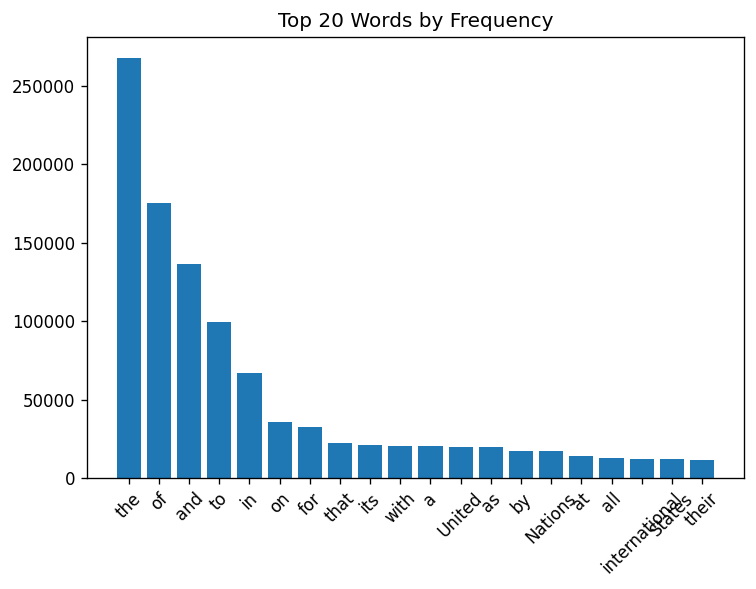

In [ ]:
# A5 — Bar chart of top 20 words
import matplotlib.pyplot as plt

top20 = word_counts.most_common(20)
words = [w for w, _ in top20]
counts = [c for _, c in top20]
#plotting
plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.tight_layout()
plt.title("Top 20 Words by Frequency")
plt.show()



**Discussion:** *Most of the top 10 words are function words like articles, prepositions, and conjunctions. They appear very often because they help build sentences, not because they carry strong meaning. This reflects Zipf’s Law, where a few words are used very frequently while most other words appear rarely.*

---
### A6 (5 pt) — Top 20 Words per Language

Go back to the **original UNCorpus TMX file** for this question.

For each of the four languages — **English** (`en`), **Arabic** (`ar`), **Spanish** (`es`), and **Russian** (`ru`) — extract all segment text and find the **top 20 most frequent words**.

> **Definition:** A *word* is any whitespace-separated token. Keep all punctuation and digits; do **not** apply any regex filtering — split only on whitespace.

**Tasks:**
1. Display a top-20 frequency table for each language.
2. Plot a **bar chart** of the top 20 words for each language.
3. **Discuss in 2–3 sentences** per language: What do the top words reveal about that language's grammatical structure? (Consider function words, clitics, articles, and prepositions.)

**Points:** 2 pt for the four frequency tables | 2 pt for the four bar charts | 1 pt for discussion.


In [ ]:
# A6 Top 20 words per language with bar charts
from collections import Counter
languages = ['en', 'ar', 'es', 'ru']

language_tokens = {}
for lang in languages:
    print(f"\n===== Language: {lang} =====")
    
    segments = re.findall(
        rf'<tuv[^>]*xml:lang="{lang}"[^>]*>.*?<seg>(.*?)</seg>',
        content,
        flags=re.DOTALL | re.IGNORECASE
    )
    text_language = ' '.join(segments)
    tokens_language = text_language.split()  
    
    language_tokens[lang] = tokens_language 
    
    counts = Counter(tokens_language)
    print(f"{'Rank':>5s} {'Word':15s} {'Count':>10s}")
    print("-" * 35)
    for rank, (word, count) in enumerate(counts.most_common(20), 1):
        print(f"{rank:5d} {word:15s} {count:10,d}")


===== Language: en =====
 Rank Word                 Count
-----------------------------------
    1 the                267,940
    2 of                 175,497
    3 and                136,607
    4 to                  99,545
    5 in                  66,802
    6 on                  35,910
    7 for                 32,327
    8 that                22,534
    9 its                 21,181
   10 with                20,349
   11 a                   20,126
   12 United              20,006
   13 as                  19,973
   14 by                  17,251
   15 Nations             16,995
   16 at                  13,933
   17 all                 12,827
   18 international       12,061
   19 States              11,986
   20 their               11,173

===== Language: ar =====
 Rank Word                 Count
-----------------------------------
    1 في                  92,685
    2 من                  45,238
    3 على                 38,530
    4 -                   34,817
    5 إلى         

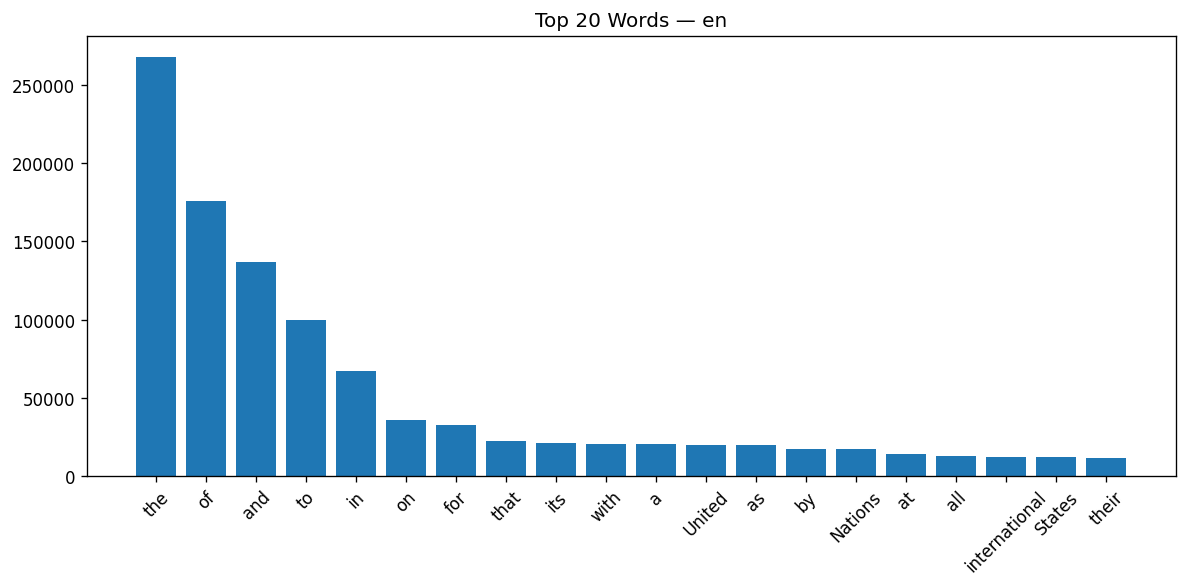

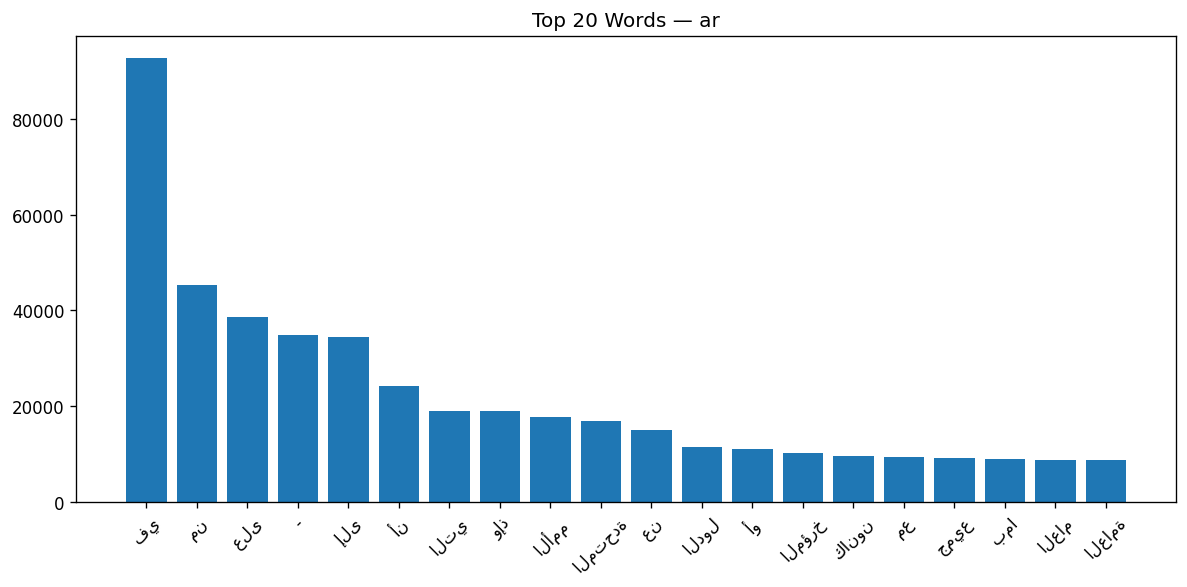

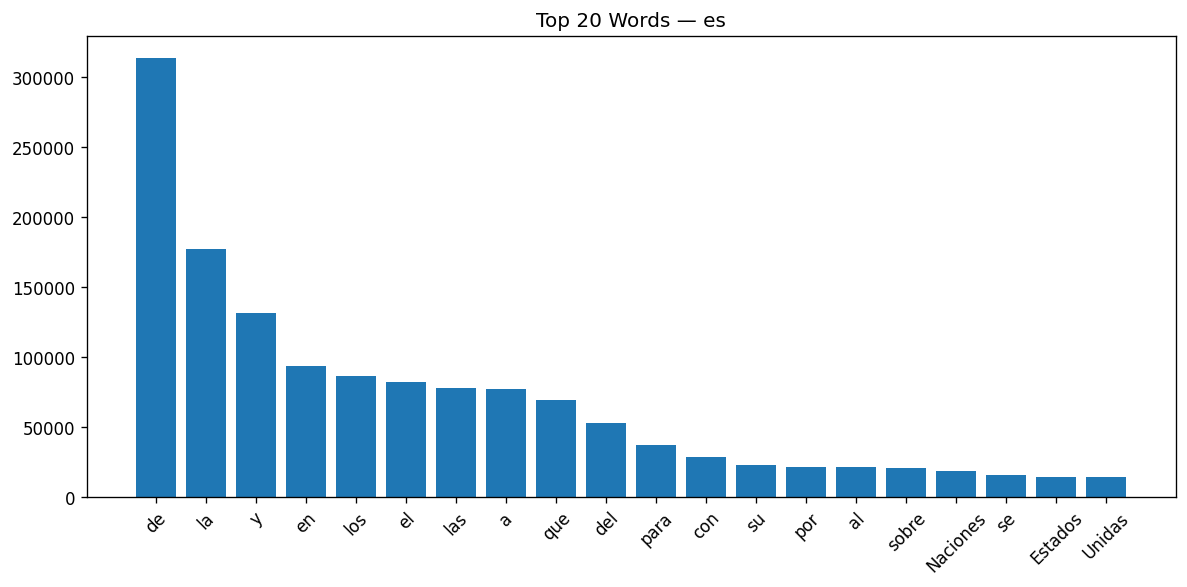

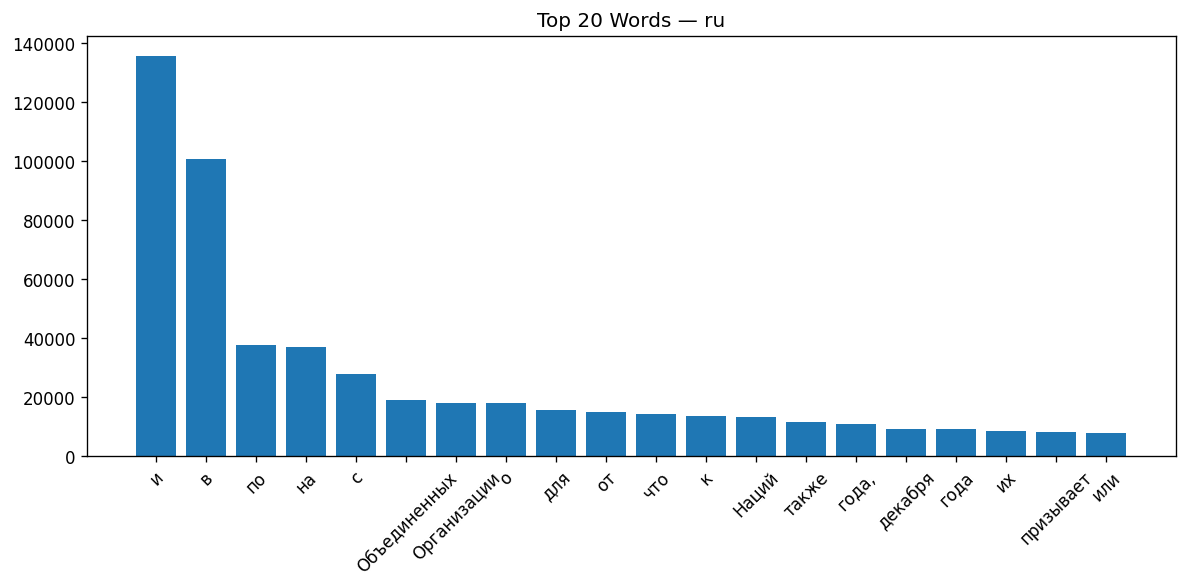

In [ ]:
# A6 — write your code here — Bar charts for all four languages
import matplotlib.pyplot as plt
from collections import Counter

for lang, tokens_lang in language_tokens.items():
    
    counts = Counter(tokens_lang)
    top20 = counts.most_common(20)
    
    words = [w for w, _ in top20]
    values = [c for _, c in top20]
    
    plt.figure(figsize=(10,5))
    plt.bar(words, values)
    plt.xticks(rotation=45)
    plt.title(f"Top 20 Words — {lang}")
    plt.tight_layout()
    plt.show()



**Discussion:** *In English and Spanish, the top words are mostly function words like articles, prepositions, and conjunctions, showing that grammar is expressed using separate words. In Arabic, some of these elements appear as attached forms(clitics), so grammatical information is often combined within the word. In Russian, there are no articles, and the language relies more on word endings(inflection) than separate function words.*

---
# Section B: Arabic Stemming and Lemmatization (30 points)

This section works with the **Arabic segments** of the UNCorpus. You will extract the Arabic text using regular expressions (building on what you learned in Section A), initialize the stemming and lemmatization tools, and analyze the results.

**Tools you will use:**

| Tool | Type | How to import |
|------|------|---------------|
| NLTK ISRI | Root-based stemmer (no dictionary) | `from nltk.stem.isri import ISRIStemmer` |
| Tashaphyne | Light stemmer + root extractor | `from tashaphyne.stemming import ArabicLightStemmer` |
| Light10 | Light stemmer — affix stripping (Larkey et al., 2002) | Implemented below |
| Alma (SinaTools) | True lemmatizer + POS tagger — SinaLab, Birzeit University | `from sinatools.morphology import morph_analyzer` |


---
### B0 (0 pt) — Extract Arabic Text and Initialize Tools

Run this cell before attempting any question in Section B.

**Your task:** Write the regex pattern to extract all Arabic segment texts from the UNCorpus. Use the same approach as A3, but target the Arabic language code `"AR"` instead of `"EN"`. The rest of the cell — stemmer initialization and Alma setup — is provided for you.


In [ ]:
# B0 — Extract Arabic segments and initialize all tools

# ── Your code: write the regex pattern to extract Arabic <seg> content ────────
# Hint: same structure as A3, but change "EN" to "AR"
ar_segments = re.findall(
    r'<tuv xml:lang="AR">\s*<seg>(.*?)</seg>',
    content, flags=re.DOTALL | re.IGNORECASE
)
ar_segments = [s.strip() for s in ar_segments if s.strip()]
ar_text     = ' '.join(ar_segments)

# Extract Arabic word tokens (Unicode Arabic block: U+0600–U+06FF)
ar_words = re.findall(r'[\u0600-\u06FF]+', ar_text)

print(f'Arabic segments extracted : {len(ar_segments):,}')
print(f'Arabic word tokens        : {len(ar_words):,}')
print(f'Arabic word types         : {len(set(ar_words)):,}')
print(f'Sample: {ar_segments[0][:100]}')

# ── Initialize stemmers (provided) ────────────────────────────────────────────
from nltk.stem.isri import ISRIStemmer
from tashaphyne.stemming import ArabicLightStemmer

isri_stemmer = ISRIStemmer()
tash_stemmer = ArabicLightStemmer()

class Light10Stemmer:
    """Reference implementation of the Light10 Arabic stemmer (Larkey et al., 2002)."""
    def __init__(self):
        self.prefixes   = ['وال', 'بال', 'كال', 'فال', 'لل', 'ال']
        self.suffixes   = ['ها', 'ان', 'ات', 'ون', 'ين', 'يه', 'ية', 'ه', 'ة', 'ي']
        self.diacritics = re.compile(r'[\u064B-\u0652\u0670]')
        self.hamza_map  = str.maketrans('أإآ', 'ااا')
    def stem(self, word):
        word = self.diacritics.sub('', word).translate(self.hamza_map)
        if len(word) > 3 and word[0] == 'و':
            word = word[1:]
        for p in sorted(self.prefixes, key=len, reverse=True):
            if word.startswith(p) and len(word) - len(p) >= 2:
                word = word[len(p):]; break
        for s in sorted(self.suffixes, key=len, reverse=True):
            if word.endswith(s) and len(word) - len(s) >= 2:
                word = word[:-len(s)]; break
        return word

light10 = Light10Stemmer()

# ── Alma (SinaTools) — downloads data files on first run ──────────────────────
ALMA_AVAILABLE = False
try:
    from sinatools.DataDownload.downloader import download_file, urls, get_appdatadir
    _app_dir  = get_appdatadir()
    _required = {
        'lemmas_dic.pickle':   'morph',
        'two_grams.pickle':    'two_grams',
        'three_grams.pickle':  'three_grams',
        'four_grams.pickle':   'four_grams',
        'five_grams.pickle':   'five_grams',
    }
    for fname, key in _required.items():
        if not os.path.exists(os.path.join(_app_dir, fname)):
            download_file(urls[key])
    from sinatools.morphology import morph_analyzer
    morph_analyzer.analyze('كتب')   # smoke test
    ALMA_AVAILABLE = True
    print('\nTools ready: ISRI | Tashaphyne | Light10 | Alma')
except Exception as e:
    print(f'\nTools ready: ISRI | Tashaphyne | Light10')
    print(f'Alma not available: {e}')
    print('Use the online demo: https://sina.birzeit.edu/alma/')

Arabic segments extracted : 72,339
Arabic word tokens        : 2,231,537
Arabic word types         : 56,552
Sample: القرار 55/100

Tools ready: ISRI | Tashaphyne | Light10 | Alma


---
### B1 (8 pt) — Vocabulary Reduction by Stemming

A primary motivation for stemming in Information Retrieval is **vocabulary reduction**: grouping different surface forms of the same word under a single stem reduces the index size and improves recall by matching words that share a common root.

**Tasks:**
1. Apply **ISRI**, **Tashaphyne**, and **Light10** to all Arabic word tokens extracted in B0.
2. For each stemmer, compute the number of unique stems produced and the vocabulary reduction percentage relative to the original unstemmed vocabulary.
3. Display the results in a comparison table.
4. **Discuss in 3–4 sentences:** Which stemmer is most aggressive (reduces vocabulary the most)? Which is most conservative? What are the trade-offs between aggressiveness and precision for IR?


In [ ]:
# B1 — Vocabulary reduction comparison
original_vocab = set(ar_words)
original_size = len(original_vocab)

# Apply each stemmer to all unique word types
isri_stems = set(isri_stemmer.stem(w) for w in original_vocab)

tash_stems = set()
for w in original_vocab:
    tash_stemmer.light_stem(w)
    tash_stems.add(tash_stemmer.get_stem())

light10_stems = set(light10.stem(w) for w in original_vocab)

# Display comparison table
print(f"{'Stemmer':<12} {'Unique Stems':>14} {'Reduction %':>12}")
print('-' * 40)
print(f"{'Original':<12} {original_size:>14,} {'0.00%':>12}")
print(f"{'ISRI':<12} {len(isri_stems):>14,} {(1 - len(isri_stems)/original_size)*100:>11.2f}%")
print(f"{'Tashaphyne':<12} {len(tash_stems):>14,} {(1 - len(tash_stems)/original_size)*100:>11.2f}%")
print(f"{'Light10':<12} {len(light10_stems):>14,} {(1 - len(light10_stems)/original_size)*100:>11.2f}%")



Stemmer        Unique Stems  Reduction %
----------------------------------------
Original             56,552        0.00%
ISRI                 20,082       64.49%
Tashaphyne           24,505       56.67%
Light10              30,743       45.64%


**Discussion:** As expected, ISRI is the most aggressive stemmer with a vocabulary reduction of 64.49%, as it attempts to extract the trilateral root rather than just stripping affixes. Light10 is the most conservative, producing the least reduction with percent of 45.64% since it only removes known prefixes and suffixes without going deeper into the word structure. The main trade-off is that aggressive stemmers like ISRI risk over-stemming and merging unrelated words under the same stem, which hurts precision in IR . On the other hand, conservative stemmers may under-stem, failing to group genuinely related word forms together and hurting recall. The ideal stemmer strikes a balance between the two extremes. choice depends on our application.

---
### B2 (7 pt) — Stemming Consistency: Do Stemmers Agree?

Different stemmers often produce different stems for the same word, which directly affects retrieval results — two documents about the same topic may not be matched if different stemmers normalize the query and document words differently.

**Tasks:**
1. Take the **50 most frequent Arabic word types** in the UNCorpus.
2. Apply **ISRI**, **Tashaphyne**, and **Light10** to each.
3. Display a table showing: word | frequency | ISRI stem | Tashaphyne stem | Light10 stem | agree?
4. Report how many of the top-50 words show full agreement across all three stemmers.
5. **Discuss in 2–3 sentences:** For words where the stemmers disagree, which stemmer produced the most useful stem for IR? Justify your answer with one specific example.


In [ ]:
# B2 — Stemming consistency on top-50 Arabic words
from collections import Counter
import pandas as pd

word_freq = Counter(ar_words)
top50 = word_freq.most_common(50)

rows = []
agree_count = 0
for word, freq in top50:
    isri_s  = isri_stemmer.stem(word)
    tash_stemmer.light_stem(word)
    tash_s  = tash_stemmer.get_stem()
    light_s = light10.stem(word)
    agree   = (isri_s == tash_s == light_s)
    if agree:
        agree_count += 1
    rows.append({
        'Word':       word,
        'Frequency':  freq,
        'ISRI':       isri_s,
        'Tashaphyne': tash_s,
        'Light10':    light_s,
        'Agree?':     'YES' if agree else 'NO'
    })

df = pd.DataFrame(rows)
print(f"Full agreement on {agree_count}/50 words.\n")
display(df)



Full agreement on 23/50 words.



,Word,Frequency,ISRI,Tashaphyne,Light10,Agree?
0,في,92705,في,في,في,YES
1,من,45262,من,من,من,YES
2,على,38552,على,على,على,YES
3,إلى,34486,الى,إلى,الى,NO
4,،,29584,،,،,،,YES
5,أن,24232,ان,أن,ان,NO
6,التي,18994,التي,التي,تي,NO
7,وإذ,18947,وإذ,إذ,واذ,NO
8,الأمم,17777,امم,أمم,امم,NO
9,المتحدة,17247,تحد,متحد,متحد,NO


**Discussion:** Out of 50 words, all three stemmers agreed on only 23, which is expected since each stemmer follows a different approach. For words where they disagree, no single stemmer is universally better,it truly depends on the application. For example, with تنفيذ, ISRI produced the the actual root نفذ, while with تشير, Tashaphyne correctly identified the root شير. Light10 is less focused on root extraction, but that is not necessarily a weakness since for basic IR tasks stripping affixes is often sufficient and avoids the over-stemming risks that come with aggressive root extraction. The best stemmer is the one that aligns with the goals of the system being built.

---
### B3 (8 pt) — Stemming vs. Lemmatization on UN Political Terms

UN General Assembly resolutions use a specialized political and legal vocabulary. Stemmers may handle these technical terms differently from everyday words, and lemmatization — which maps each word to its dictionary headword — may be more appropriate for this domain.

**Tasks:** Apply all four tools to the following 15 politically significant Arabic terms that commonly appear in UN resolutions:

```
الأمم، المتحدة، الأمن، السلام، الحقوق، الإنسانية، القرار، التنمية،
الديمقراطية، الاحتلال، الإرهاب، المفاوضات، الاستقلال، السيادة، العدالة
```

1. Apply **ISRI**, **Tashaphyne**, and **Light10** to each word.
2. If Alma is available in your environment, apply it and include the diacritized lemma. Otherwise, look up each word at [sina.birzeit.edu/alma](https://sina.birzeit.edu/alma/) and fill in the Alma column manually.
3. Display a comparison table.
4. **Discuss in 3–4 sentences:** For a retrieval system operating on UN Arabic documents, which tool would you recommend and why? Address both precision (not merging unrelated words) and recall (grouping genuinely related word forms).


In [ ]:
# B3 — write your code here — Political terms: stemmers vs. lemmatizer
import pandas as pd
political_words = [
    'الأمم', 'المتحدة', 'الأمن', 'السلام', 'الحقوق',
    'الإنسانية', 'القرار', 'التنمية', 'الديمقراطية', 'الاحتلال',
    'الإرهاب', 'المفاوضات', 'الاستقلال', 'السيادة', 'العدالة',
]

alma_manual = {
    'الأمم':        '',
    'المتحدة':      '',
    'الأمن':        '',
    'السلام':       '',
    'الحقوق':       '',
    'الإنسانية':    '',
    'القرار':       '',
    'التنمية':      '',
    'الديمقراطية':  '',
    'الاحتلال':     '',
    'الإرهاب':      '',
    'المفاوضات':    '',
    'الاستقلال':    '',
    'السيادة':      '',
    'العدالة':      '',
}

rows = []
for word in political_words:
    isri_s  = isri_stemmer.stem(word)
    tash_stemmer.light_stem(word)
    tash_s  = tash_stemmer.get_stem()
    light_s = light10.stem(word)

    if ALMA_AVAILABLE:
        alma_result = morph_analyzer.analyze(word)
        alma_s = alma_result[0]['lemma'] if alma_result else ''
    else:
        alma_s = alma_manual.get(word, '')

    rows.append({
        'Word':       word,
        'ISRI':       isri_s,
        'Tashaphyne': tash_s,
        'Light10':    light_s,
        'Alma':       alma_s,
    })

df = pd.DataFrame(rows)
display(df)



,Word,ISRI,Tashaphyne,Light10,Alma
0,الأمم,امم,أمم,امم,أُمَّةٌ
1,المتحدة,تحد,متحد,متحد,مُتَّحِدٌ
2,الأمن,امن,أمن,امن,أَمْنٌ
3,السلام,سلم,سلام,سلام,سَلَامٌ
4,الحقوق,حقق,حقوق,حقوق,حَقٌّ
5,الإنسانية,سان,إنسان,انسان,إِنْسَانِيٌّ
6,القرار,قرر,قرار,قرار,قَرَارٌ
7,التنمية,نمي,تنم,تنم,تَنْمِيَةٌ
8,الديمقراطية,ديمقراطية,ديمقراط,ديمقراط,دِيمُقْرَاطِيٌّ
9,الاحتلال,حلل,احتلال,احتلال,اِحْتِلاَلٌ


**Discussion:** *For a retrieval system operating on UN Arabic documents, Alma is the most recommended tool since it returns precise diacritized lemmas reflecting the true dictionary form, which is critical for a specialized political and legal domain where merging unrelated terms iscostly. For example, ISRI stemmed الاستقلال to قل which is is an over-stemming error that would merge unrelated words such as قليل , hurting precision significantly. Light10 and Tashaphyne performed reasonably well on most terms, making them acceptable alternatives when Alma is unavailable. Alma also has good recall since in this domain we will not need words smaller than what we got using Alma -we would get better recall using root not lemma tho but not neccassary in our case-*

---
### B4 (7 pt) — Over-Stemming in the Arabic UNCorpus

**Over-stemming** occurs when two or more words with different meanings are mapped to the same stem, causing the retrieval system to treat them as equivalent. This is a form of false positive: a document about one concept is retrieved in response to a query about a different concept, simply because they share a root.

**Tasks:**
1. Apply **ISRI stemming** to all Arabic word types in the UNCorpus.
2. Find all stems that are shared by **5 or more different original word types** — each such stem is a candidate for over-stemming.
3. Display the **top 10 most over-stemmed** stems: for each, show the stem, the number of original words that map to it, and up to 8 of those words.
4. **Discuss in 2–3 sentences:** Choose one stem from your top 10 and explain whether grouping all those words together would help or hurt a UN document retrieval system.


In [ ]:
# B4 Over-stemming analysis
import pandas as pd
from collections import defaultdict

# Apply ISRI to all unique Arabic word types
stem_to_words = defaultdict(set)
for word in set(ar_words):
    stem = isri_stemmer.stem(word)
    stem_to_words[stem].add(word)

# Find stems shared by 5 or more words
over_stemmed = {stem: words for stem, words in stem_to_words.items() if len(words) >= 5}

# Sort by number of words mapped to each stem (descending)
top10 = sorted(over_stemmed.items(), key=lambda x: len(x[1]), reverse=True)[:10]

# Display table
rows = []
for stem, words in top10:
    sample = ', '.join(list(words)[:8])
    rows.append({
        'Stem':        stem,
        'Word Count':  len(words),
        'Sample Words (up to 8)': sample
    })

df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', None)
display(df)



,Stem,Word Count,Sample Words (up to 8)
0,عمل,224,"وبعملها, العاملات, ونعمل, للمعاملة, إعمالا, بالمعاملة, وعمالتهم, للعوامل"
1,جمع,223,"والمجتمعي, والاجتماعات, والاجتماعيين, وللجمعية, وتجمعات, المجتمعين, اجتمعوا, وجميع"
2,قرر,204,"ستقرره, تقرره, تقرير, المقرَّر, تقاريرهم, وبمقرري, إقرارها, لقراري"
3,عرض,185,"معرِّضين, معروضة, معرضات, عُرض, المعرّضين, يعرضه, الاستعراضين, لعرضها"
4,نظم,174,"النظاميين, منتظم, ومنظمات, التنظيمي, والمنظمات, وتنظيمه, النظامين, بنظم"
5,وقع,145,"والتوقيعات, موقَّعة, لمواقع, وقعت, توقع, وبوقوعهم, وموقعها, وقاع"
6,مثل,136,"تمثيلهم, للممثلين, سيمثل, وممثلي, وممثّلة, ممثلين, وللممثل, ممثلا"
7,طلب,136,"الطلب, ويطالب, مطلوبة, طلبا, مطلب, مُطالِب, ومطالبة, والطلبان"
8,قدم,135,"وتقديمها, للتقدم, ويقدمه, وبتقدم, بالتقادم, والتقادم, القديم, تقدمهما"
9,علم,133,"تعلم, بالتعلم, تعليمه, علماً, المعلومات, بعلم, علوم, أعلام"


**Discussion:** *as we can see in the table above showing the most over stemming cases we can see mapping words that are quite unrelated to the same root which is the exact meaning of over stemming. example :in قدم it maps to both تقادم -getting old- and تقدم -moving forward- which are two unrelated words. and this is will cause connecting them and retaring inaccurate documants. and this is why we should always find a balance between precision and recall (in this example we have low precision with high recall).*

---
## Grading Summary

### Section A — Regular Expressions (70 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| A0 | Worked example — Human Rights | 0 | |
| A1 | XML structure of the UNCorpus | 5 | |
| A2a | Number of lines in the corpus | 2.5 | |
| A2b | Lines containing `<seg>` | 2.5 | |
| A2c | Lines with no `<seg>` tag | 2.5 | |
| A2d | Number of English segments | 2.5 | |
| A3 setup | English plain-text extraction | 5 | |
| A3a | Total word tokens | 4 | |
| A3b | Unique word types (case-sensitive) | 4 | |
| A3c | Unique word types (case-insensitive) | 4 | |
| A3d | Digit-only tokens | 4 | |
| A3e | Mixed numeric tokens | 4 | |
| A4 setup | Alphabetic types extraction | 3 | |
| A4a–A4d | Substring matching for 'war' (3 pt each) | 12 | |
| A5 | Frequency histogram + bar chart + discussion | 10 | |
| A6 | Top-20 words per language + bar charts + discussion | 5 | |
| | **Section A Total** | **70** | |

### Section B — Arabic Stemming and Lemmatization (30 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| B0 | Extract Arabic text + initialize tools | 0 | |
| B1 | Vocabulary reduction by stemmer | 8 | |
| B2 | Stemming consistency — top-50 Arabic words | 7 | |
| B3 | Stemming vs. lemmatization on UN political terms | 8 | |
| B4 | Over-stemming analysis | 7 | |
| | **Section B Total** | **30** | |

### Final Grade

| Section | Points | Your Points |
|---------|--------|-------------|
| Section A — Regular Expressions | 70 | |
| Section B — Arabic Stemming and Lemmatization | 30 | |
| **Total** | **100** | |

---
**End of Assignment** | ENCS5342 — Information Retrieval with Applications of NLP | Birzeit University
